# 06. Thermal Energy Storage (TES)

Model 05 showed a mismatch: heat pump output tends to spike whenever renewable electricity is cheap
or plentiful, while heat demand follows its own slower, weather-driven seasonal curve. A battery
could theoretically absorb that mismatch by storing electricity instead, but storing *heat* directly
is both simpler and dramatically cheaper — a hot water tank has no electrochemistry, no degradation
cycle limits, and no need for expensive power electronics.

The objective is to extend the Model 05 system (10 MW Solar PV + 15 MW Wind + 4 MW/8 MWh Battery +
3 MW Heat Pump + industrial and heat demand) with a **40 MWh thermal store**, sitting directly on
`heat_bus` between the heat pump and the heat demand.

## 🛠️ System Topology
1. **Buses:** `electricity_bus` and `heat_bus`, unchanged from Model 05.
2. **Generators (Source):** Solar PV (10 MW) and Wind (15 MW), unchanged.
3. **Generators (Grid, two-directional):** `Grid_Import` and `Grid_Export`, unchanged.
4. **Loads:** `Industrial_Load` and `Heat_Demand`, unchanged.
5. **Storage:** The `Battery` (electricity), unchanged, plus a new `Thermal_Storage` — a `Store`
   component on `heat_bus`, defined purely by an energy capacity (`e_nom`), since a hot water tank
   has no meaningful power rating limit the way a battery's electrochemistry does.
6. **Links:** `Heat_Pump`, unchanged.

### Why TES is cheaper than BESS for shifting energy
A `StorageUnit` like the battery needs power electronics (inverters, converters) rated for its full
charge/discharge power, on top of the energy-storage medium itself — that's why batteries are
described by *both* a power rating and a duration. A `Store` like a hot water tank is, in the
simplest case, just an insulated volume of water: there's no equivalent power-electronics cost, so
its capital cost scales with energy capacity (EUR/MWh) alone, typically at a small fraction of a
battery's EUR/MWh cost. This is why thermal storage is used aggressively in real district heating
systems even when battery storage remains too expensive to deploy at the same scale.

<img src="../assets/model_6.jpg" alt="Model 06 System Topology" width="800">


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all three dataframes to use this clean index
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

All electricity-side and heat pump parameters are carried over unchanged from Model 05. A new
`thermal_storage` entry defines the tank's energy capacity and standing (self-discharge) loss.


In [2]:
# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,          # Nominal capacity of the solar PV system in MW
        'marginal_cost': 0.0    # Marginal cost of solar PV generation in $/MWh
    },
    'wind': {
        'p_nom': 15.0,          # Nominal capacity of the wind plant in MW
        'marginal_cost': 0.0    # Marginal cost of wind generation in $/MWh
    },
    'market_grid': {
        'import_p_nom': 20.0,   # Maximum import capacity from the grid
        'export_p_nom': 18.0    # Maximum export capacity to the grid
    },
    'demand': {
        'day_load_mw': 8.0,     # Electrical load during working hours (08:00-18:00)
        'night_load_mw': 4.0    # Electrical load outside working hours
    },
    'battery': {
        'p_nom': 4.0,                # Charge/discharge power rating in MW
        'max_hours': 2.0,            # Duration -> 4 MW x 2h = 8 MWh usable capacity
        'efficiency_store': 0.95,    # Charging efficiency
        'efficiency_dispatch': 0.95  # Discharging efficiency (round-trip ~ 90%)
    },
    'heat_pump': {
        'p_nom': 3.0,            # Electrical input rating in MW
        'cop': 3.5,              # Coefficient of Performance (fixed)
        'marginal_cost': 0.5     # Small O&M cost per MWh of heat output
    },
    'heat_demand': {
        'avg_mw': 3.0,           # Average district heating demand
        'amplitude_mw': 2.0      # Seasonal swing around the average (winter-high)
    },
    'thermal_storage': {
        'e_nom': 40.0,           # Usable energy capacity in MWh
        'standing_loss': 0.01    # Hourly self-discharge (heat loss to surroundings)
    }
}


## 🏗️ Initializing the Network

The topology is unchanged from Model 05 — still `electricity_bus` and `heat_bus`. The thermal store,
added later, attaches only to `heat_bus`.


In [3]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Add both energy-carrier buses
n.add("Bus", "electricity_bus")
n.add("Bus", "heat_bus")


Index(['heat_bus'], dtype='object')

## ⚡ Adding Generators and the Grid Connection

Solar, Wind, `Grid_Import`, and `Grid_Export` are added exactly as in Model 05.


In [4]:
# 1. Add the Solar PV generator
n.add("Generator",
      "Solar_PV",
      bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

# 2. Add the Wind generator
n.add("Generator",
      "Wind",
      bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

# 3. Add the Grid Import generator (covers any shortfall)
n.add("Generator",
      "Grid_Import",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

# 4. Add the Grid Export Market Sink (sells any surplus)
n.add("Generator",
      "Grid_Export",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0,
      p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Adding the Electrical and Heat Demands

Unchanged from Model 05.


In [5]:
# Electrical load: same day/night industrial shape as Models 03-05
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
electrical_load = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
electrical_load = pd.Series(electrical_load, index=n.snapshots)

n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=electrical_load)

# Heat load: same seasonal (winter-high) shape as Model 05
day_of_year = n.snapshots.dayofyear
heat_load = tech_param['heat_demand']['avg_mw'] - tech_param['heat_demand']['amplitude_mw'] * np.sin(
    (day_of_year - 80) * 2 * np.pi / 365
)
heat_load = pd.Series(np.clip(heat_load, 0.2, None), index=n.snapshots)

n.add("Load", "Heat_Demand", bus="heat_bus", p_set=heat_load)


Index(['Heat_Demand'], dtype='object')

## 🔋 Adding the Battery and 🔗 the Heat Pump

Both unchanged from Model 05, still on `electricity_bus` and bridging to `heat_bus` respectively.


In [6]:
n.add("StorageUnit",
      "Battery",
      bus="electricity_bus",
      p_nom=tech_param['battery']['p_nom'],
      max_hours=tech_param['battery']['max_hours'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)

n.add("Link",
      "Heat_Pump",
      bus0="electricity_bus",
      bus1="heat_bus",
      p_nom=tech_param['heat_pump']['p_nom'],
      efficiency=tech_param['heat_pump']['cop'],
      marginal_cost=tech_param['heat_pump']['marginal_cost'])


Index(['Heat_Pump'], dtype='object')

## 🌡️ Adding the Thermal Store

A `Store` is defined purely by its energy capacity (`e_nom`) — unlike a `StorageUnit`, it has no
separate power rating, since nothing about a hot water tank inherently limits how fast it can be
filled or drained (in practice this is set by pipe sizing, but that's a much smaller cost driver than
battery power electronics). `standing_loss` represents the tank losing a small fraction of its stored
heat to its surroundings every hour, and `e_cyclic=True` applies the same "no free lunch" logic used
for the battery's state of charge.


In [7]:
n.add("Store",
      "Thermal_Storage",
      bus="heat_bus",
      e_nom=tech_param['thermal_storage']['e_nom'],
      e_cyclic=True,
      standing_loss=tech_param['thermal_storage']['standing_loss'])


Index(['Thermal_Storage'], dtype='object')

## 🧠 Running the Optimization

With both storage components now in the network, the solver optimizes electricity and heat jointly
across the full year — deciding not just how much heat to produce, but when, taking advantage of the
thermal store to decouple heat pump operation from heat demand.


In [8]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Net Cost, Import minus Export Revenue): €{n.objective:,.2f}")


Index(['Thermal_Storage'], dtype='object', name='Store')
Index(['electricity_bus', 'heat_bus'], dtype='object', name='Bus')
Index(['Heat_Pump'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 30.74it/s]
INFO:linopy.io: Writing time: 1.44s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87600 primals, 192720 duals
Objective: -1.13e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, St

Solver Status: ok
Total Objective Value (Net Cost, Import minus Export Revenue): €-1,129,601.70


## 📊 Analyzing the Results

To see the thermal store doing its job, we compare heat pump output against heat demand over a
sample week alongside the store's energy level. A well-utilized store should visibly fill up when the
heat pump is producing a surplus (typically driven by cheap or abundant electricity), and drain to
cover demand in the hours when the heat pump throttles back.


Heat Pump Output:              27,678.08 MWh
Total Heat Demand:             26,280.00 MWh
----------------------------------------
Thermal Storage Charged:       15,227.16 MWh
Thermal Storage Discharged:    13,829.08 MWh
Standing Losses:               1,398.08 MWh


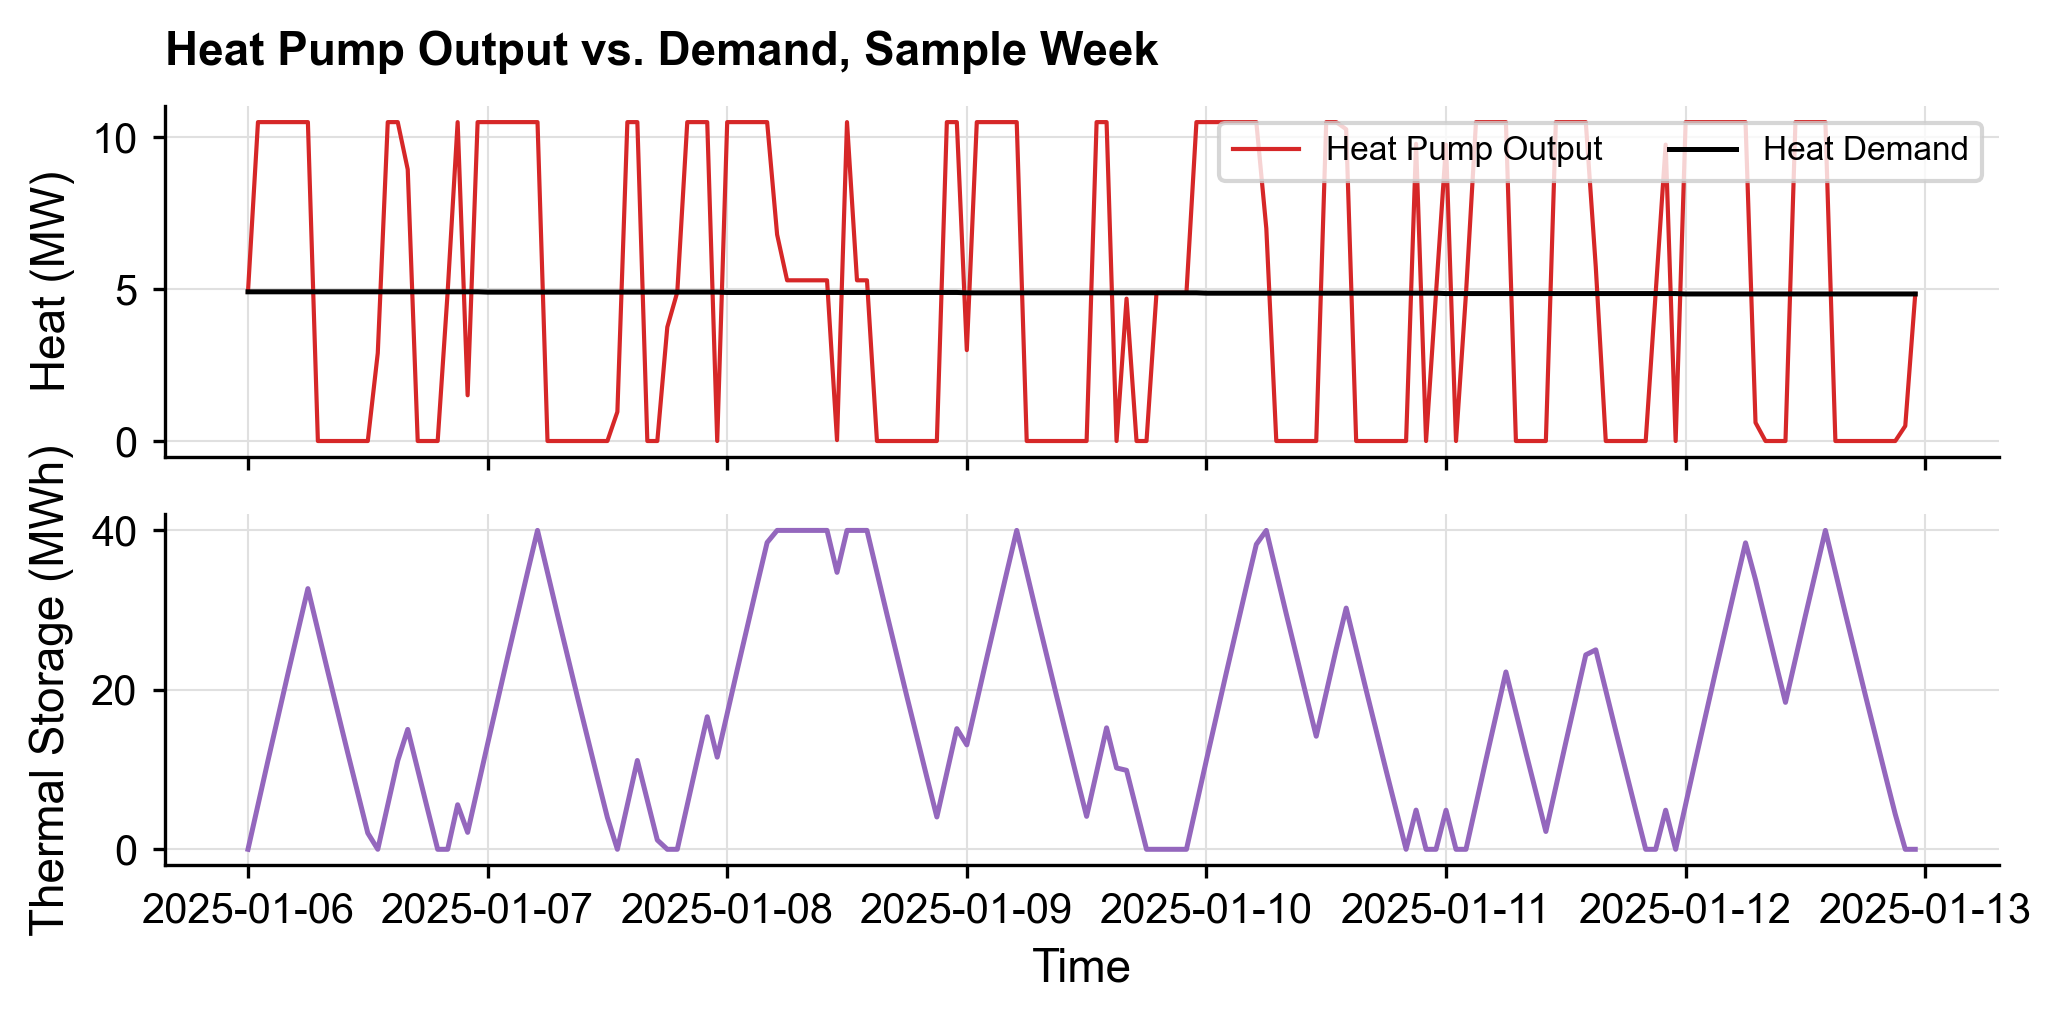

In [9]:
# Calculate Annual Totals
heat_pump_output_mwh = -n.links_t.p1['Heat_Pump'].sum()
heat_demand_mwh = heat_load.sum()
storage_charged_mwh = -n.stores_t.p['Thermal_Storage'].clip(upper=0).sum()
storage_discharged_mwh = n.stores_t.p['Thermal_Storage'].clip(lower=0).sum()

print(f"Heat Pump Output:              {heat_pump_output_mwh:,.2f} MWh")
print(f"Total Heat Demand:             {heat_demand_mwh:,.2f} MWh")
print("-" * 40)
print(f"Thermal Storage Charged:       {storage_charged_mwh:,.2f} MWh")
print(f"Thermal Storage Discharged:    {storage_discharged_mwh:,.2f} MWh")
print(f"Standing Losses:               {storage_charged_mwh - storage_discharged_mwh:,.2f} MWh")

# Plot one representative week: heat pump output, heat demand, and storage level
week = (n.snapshots >= '2025-01-06') & (n.snapshots < '2025-01-13')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(n.snapshots[week], -n.links_t.p1['Heat_Pump'][week], color='#d62728', linewidth=1.0, label='Heat Pump Output')
ax1.plot(n.snapshots[week], heat_load[week], color='black', linewidth=1.2, label='Heat Demand')
ax1.set_ylabel('Heat (MW)')
ax1.set_title('Heat Pump Output vs. Demand, Sample Week', pad=10, loc='left', fontweight='bold')
ax1.legend(loc='upper right', ncol=2, fontsize=8)

ax2.plot(n.snapshots[week], n.stores_t.e['Thermal_Storage'][week], color='#9467bd', linewidth=1.2)
ax2.set_ylabel('Thermal Storage (MWh)')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()
